# Advanced GNNs functionalities: truncated graphs and long range interactions
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/adv_gnn_advanced.ipynb)


Prerequisites: 
- GNN-based CVs tutorial

Reference papers: 
- _Zhang, Bonati, Trizio, Zhang, Kang, Hou, and Parrinello, [JCTC](https://doi.org/10.1021/acs.jctc.4c01197) (2025), [ArXiv](https://arxiv.org/abs/2409.07339)_
- _Kang, Zhang, Trizio, Hou, and Parrinello, [JCTC](https://doi.org/10.1021/acs.jctc.5c01848) (2026), [ArXiv](https://arxiv.org/abs/2510.18018)_


Author: Enrico Trizio

---

### Colab setup

In [1]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

## Overview
GNN models are much more complex than the descriptor-based counterparts as they directly process atomic coordinates.
This higher complexity also results in a wide array of possibilities in the graph definition with different schemes that are better suited for different scenarios to improve the performance while keeping the computational cost as low as reasonably possible.

In this tutorial, we will explain two advanced approaches for GNN-based MLCVs:
- **Truncated graphs**, in which the input graph is built only within a cutoff from a subset of atoms (the `system` atoms), which are still allowed to interact with the `environment` atoms that are within the cutoff but not beyond that. This approach is very convenient, for example, when describing interactions of molecules with solvents or surfaces, where only the atoms close to the molecule are relevant whereas the others can be neglected with potenitally huge computational savings.

- **Long range interactions**, in which a `long_range_cutoff`, larger than the standard one, is defined for a `subsystem` to keep connectivity at larger distances so that information can still be propagated between such nodes. This approach is convenient, for example, when large conformational changes can occur in the system, for instance, in binding/unbinding and association/dissociation processes.

<center><img src="images/truncated_graph.png" width="500" /></center>

More details about the two approaches are provided in the correpsonding sections of the tutorial.

---

## Truncated graphs

In many cases, including all the atoms in the simulation cell into the input graph is not the best choice, computationally and conceptually.
For instance, the interaction of a molecule with an environment (e.g., a solvent or a surface) is rather local, with the molecule interacting only with a reduced neighborhood of atoms rather than with the whole environment.
It follows that, in such cases, not all the atoms of the environment need to be included in the graph, thus providing significant computational savings thanks to simpler and smaller input graphs.

- **Selection**

    In `mlcolvar`, this scenario is implemented as a *truncated graph* based on the definition of two atomic subsets from the whole simulation box:
    - `system_selection`: the *reactive* part of the system, e.g., the molecule in the example above. Information from the `system_atoms` is used both to update the GNN through the layers and for the final readout.
    - `environment_selection`: the *non-reactive* part of the system, e.g., the surface/solvent in the example above. Information from the `environment_atoms` is used to update the GNN through the layers but **not** for the final readout.


- **Graph construction**

    Based on these subsets, the graph is built following a two-step procedure:
    1. **Pre-selection of nodes**: non relevant atoms are filtered out from the whole original simulation cell, thus reducing the nodes on which the graph will be built. 
    To this aim, `system_atoms` are always included as nodes, whereas `enivronment_atoms` are included as nodes only if they are within a `cutoff+buffer` from one of the `system_atoms`. `cutoff` is the same cutoff used for drawing edges later, while the additional `buffer` is applied to have a more stable behaviour of the graph when `environment_atoms` are close to the border of the selected region.
    2. **Edge placement**: edges are drawn between nodes that are within a `cutoff` from each other.


- **Readout**

    The readout, both graph-level following a pooling or node-level, is limited to the `system_atoms`.


**NOTE**

To create/handle these advanced graphs it is **highly recommended** to use the util function `create_dataset_from_trajectories`

###  Load data
To create/handle these advanced graphs it is **highly recommended** to use the util function `create_dataset_from_trajectories`.
There, the keys `system_selection` and `environment_selection` can be used to conveniently select the atoms corresponing to the system and the environment using the `MDtraj` selection syntax and the `buffer` key can be used to define the buffer region around the cutoff used for the preselection of the nodes.

In [2]:
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_trajectories

# loading arguments 
# same as to laod_dataframe
load_args = [{'start' : 0, 'stop' : 500, 'stride' : 1},
               {'start' : 0, 'stop' : 500, 'stride' : 1}
               ]

# create dataset
dataset = create_dataset_from_trajectories(
    trajectories=["https://github.com/EnricoTrizio/nacl_gnn_data/raw/refs/heads/main/UNBOUND/traj.xyz",     
                  "https://github.com/EnricoTrizio/nacl_gnn_data/raw/refs/heads/main/BOUND/traj.xyz"],
    topologies=None,               
    cutoff=4.0,  # Angstrom   
    buffer=3.0,   # Angstrom     
    system_selection='type Na or type Cl',
    environment_selection='type O',
    load_args=load_args,
    )
print('Dataset info:\n', dataset, end="\n\n")

# load dataset into a DictModule
datamodule = DictModule(dataset=dataset)
print('Datamodule info:\n', datamodule)

/home/etrizio@iit.local/Bin/dev/mlcolvar/mlcolvar/data/graph/utils.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


Dataset info:
 DictDataset( "data_list": 1000,
	    metadata={"atomic_numbers": [8, 11, 17],
		      "cutoff": 4.0,
		      "buffer": 3.0,
		      "long_range_cutoff": -1.0,
		      "used_idx": tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143

### Visualize the truncated graph
The generated dataset can be saved as an `extxyz` using the `save_dataset_configurations_as_extxyz` utils.
This way, one can visualize which atoms are included in the graph, for example by comparing the selected atoms with the original complete system with a visualization software that supports dynamics extxyz files.

In [3]:
from mlcolvar.data.utils import save_dataset_configurations_as_extyz
save_dataset_configurations_as_extyz(dataset, 'test.xyz')

### GNN-model initialization

The GNN model can be initialized from the generated dataset using the `dataset_for_initialization` to make it simpler to inherit all the parameters used in the construction of the graphs.

In [4]:
from mlcolvar.core.nn.graph.schnet import SchNetModel

gnn_model = SchNetModel(n_out=1,
                        dataset_for_initialization=dataset,
                        pooling_operation="mean",
                        n_bases=16,
                        n_layers=2,
                        n_filters=16,
                        n_hidden_channels=16,
                        w_out_after_pool=True,
                        aggr='mean'
                    )

### CV model initialization

In [5]:
import torch
from mlcolvar.cvs import DeepTDA

# we can still set the options for the optimizer the usual way
# options for the BLOCKS of the cv are disabled when passing an external model
options = {'optimizer' : {'lr' : 1e-3},
           'lr_scheduler': {
            'scheduler': torch.optim.lr_scheduler.ExponentialLR,
            'gamma': 0.9999}
        }

model = DeepTDA(n_states=2,
                n_cvs=1,
                target_centers=[-7, 7],
                target_sigmas=[0.2, 0.2],
                model=gnn_model)

/home/etrizio@iit.local/Bin/miniconda3/envs/graph_mlcolvar_test_2.5/lib/python3.9/site-packages/lightning/pytorch/utilities/parsing.py:198: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


### Model training

In [6]:
from lightning import Trainer
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
import matplotlib.pyplot as plt

# define callbacks
metrics = MetricsCallback()

# here the number of epochs is low for testing, you should increase it for applications
trainer = Trainer(
    callbacks=[metrics],
    logger=False,
    enable_checkpointing=False,
    max_epochs=300,
    enable_model_summary=False
)

trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/etrizio@iit.local/Bin/miniconda3/envs/graph_mlcolvar_test_2.5/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:492: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/home/etrizio@iit.local/Bin/miniconda3/envs/graph_mlcolvar_test_2.5/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/etrizio@iit.local/Bin/miniconda3/envs/graph_mlcolvar_test_2.5/lib/python3.9/site-packages/lightning/pytorch/utilities/data.py:77: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/etrizio@iit.local/Bin/miniconda3/envs/graph

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


#### Check training metrics

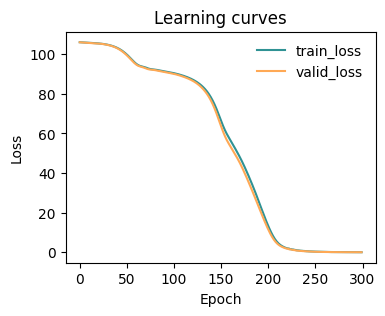

In [7]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
plot_metrics(metrics.metrics,
                  keys=['train_loss', 'valid_loss'],
                  colors=['fessa1', 'fessa5'],
                  yscale='linear',
                  ax = ax)

#### Check training outcome in CV space

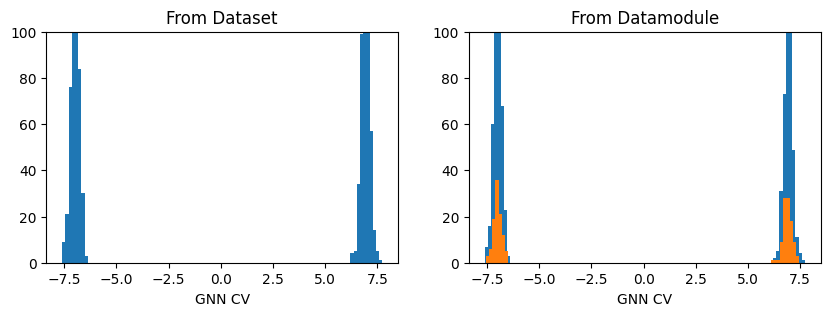

In [8]:
fig, axs = plt.subplots(1,2, figsize=(10,3))

ax = axs[0]
out_graph = model(dataset.get_graph_inputs())
ax.hist(out_graph.detach().squeeze(), bins=100)
ax.set_title('From Dataset')
ax.set_xlabel('GNN CV')
ax.set_ylim(0,100)

ax = axs[1]
out_graph = model(datamodule.get_graph_inputs("train"))
ax.hist(out_graph.detach().squeeze(), bins=100)
out_graph = model(datamodule.get_graph_inputs("valid"))
ax.hist(out_graph.detach().squeeze(), bins=100)

ax.set_title('From Datamodule')
ax.set_xlabel('GNN CV')
ax.set_ylim(0,100)
plt.show()

### Export model for inference

The exported module can then be used in PLUMED using the GNN-based C++ interfaces provided in the `plumed_interfaces` folder of the library.

In [19]:
traced_model = model.to_torchscript('model.pt', method='trace')

## Long-range interactions

When the *truncated_graph* strategy is applied, for certain process, it may happen that, rather having a single and continuous graph in which all the `system_atoms` are included, one has separated graphs built around subsets of the `system_atoms`.
For instance, if one considers the dissociation of a ion pair in a solvent, in the bound state the ions are close to each other and will thus be part of the same graphs, whereas in the unbound state they are likely to be far from each beyond the cutoff+buffer radius, thus being confined to disconnected graphs

To overcome this possible limitation, it is useful to allow `system_atoms` to interact with each other according to a `long_range_cutoff`, larger than the normal cutoff, which is used exclusively used to draw edges between the `subsystem_atoms`, a subset of the `system_atoms`.

###  Load data
To create/handle these advanced graphs it is **highly recommended** to use the util function `create_dataset_from_trajectories`.
There, besides the keys `system_selection`, `environment_selection` and `buffer` used for the truncated graph definition, the `long_range_cutoff` key can be used to define the long range cutoff taht will be applied to draw the edges between the atoms selected with the `subsystem_selection` keyword. 

Note that `subsystem_selection` must be a subset of the `system_selection`.

In [10]:
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_trajectories

# loading arguments 
# same as to laod_dataframe
load_args = [{'start' : 0, 'stop' : 500, 'stride' : 1},
               {'start' : 0, 'stop' : 500, 'stride' : 1}
               ]

# create dataset
dataset = create_dataset_from_trajectories(
    trajectories=["https://github.com/EnricoTrizio/nacl_gnn_data/raw/refs/heads/main/UNBOUND/traj.xyz",     
                  "https://github.com/EnricoTrizio/nacl_gnn_data/raw/refs/heads/main/BOUND/traj.xyz"],
    topologies=None,               
    cutoff=4.0,  # Angstrom   
    buffer=3.0,   # Angstrom
    system_selection='type Na or type Cl',
    subsystem_selection='type Na or type Cl',
    long_range_cutoff=10.0, # Angstrom     
    environment_selection='type O',
    load_args=load_args,
    )
print('Dataset info:\n', dataset, end="\n\n")

# load dataset into a DictModule
datamodule = DictModule(dataset=dataset)
print('Datamodule info:\n', datamodule)

Dataset info:
 DictDataset( "data_list": 1000,
	    metadata={"atomic_numbers": [8, 11, 17],
		      "cutoff": 4.0,
		      "buffer": 3.0,
		      "long_range_cutoff": 10.0,
		      "used_idx": tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143

### Visualize the truncated graph
The generated dataset can be saved as an `extxyz` using the `save_dataset_configurations_as_extxyz` utils.
This way, one can visualize which atoms are included in the graph, for example by comparing the selected atoms with the original complete system with a visualization software that supports dynamics extxyz files.

In [11]:
from mlcolvar.data.utils import save_dataset_configurations_as_extyz
save_dataset_configurations_as_extyz(dataset, 'test.xyz')

### GNN-model initialization

The GNN model can be initialized from the generated dataset using the `dataset_for_initialization` to make it simpler to inherit all the parameters used in the construction of the graphs.

In [12]:
from mlcolvar.core.nn.graph.schnet import SchNetModel

gnn_model = SchNetModel(n_out=1,
                        dataset_for_initialization=dataset,
                        pooling_operation="mean",
                        n_bases=16,
                        n_layers=2,
                        n_filters=16,
                        n_hidden_channels=16,
                        w_out_after_pool=True,
                        aggr='mean'
                    )

### CV model initialization

In [13]:
import torch
from mlcolvar.cvs import DeepTDA

# we can still set the options for the optimizer the usual way
# options for the BLOCKS of the cv are disabled when passing an external model
options = {'optimizer' : {'lr' : 1e-3},
           'lr_scheduler': {
            'scheduler': torch.optim.lr_scheduler.ExponentialLR,
            'gamma': 0.9999}
        }

model = DeepTDA(n_states=2,
                n_cvs=1,
                target_centers=[-7, 7],
                target_sigmas=[0.2, 0.2],
                model=gnn_model)

### Model training

In [14]:
from lightning import Trainer
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
import matplotlib.pyplot as plt

# define callbacks
metrics = MetricsCallback()

# here the number of epochs is low for testing, you should increase it for applications
trainer = Trainer(
    callbacks=[metrics],
    logger=False,
    enable_checkpointing=False,
    max_epochs=300,
    enable_model_summary=False
)

trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


#### Check training metrics

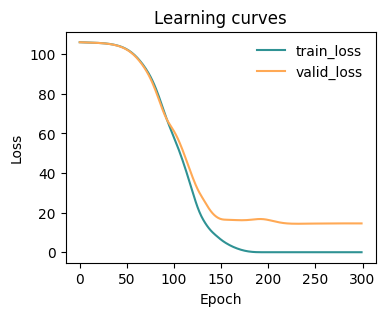

In [15]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
plot_metrics(metrics.metrics,
                  keys=['train_loss', 'valid_loss'],
                  colors=['fessa1', 'fessa5'],
                  yscale='linear',
                  ax = ax)

#### Check training outcome in CV space

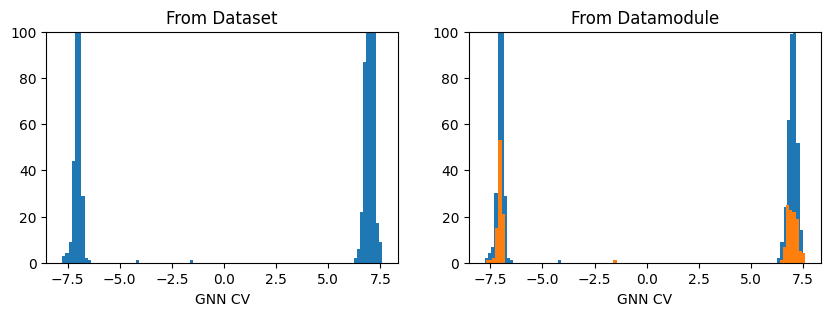

In [16]:
fig, axs = plt.subplots(1,2, figsize=(10,3))

ax = axs[0]
out_graph = model(dataset.get_graph_inputs())
ax.hist(out_graph.detach().squeeze(), bins=100)
ax.set_title('From Dataset')
ax.set_xlabel('GNN CV')
ax.set_ylim(0,100)

ax = axs[1]
out_graph = model(datamodule.get_graph_inputs("train"))
ax.hist(out_graph.detach().squeeze(), bins=100)
out_graph = model(datamodule.get_graph_inputs("valid"))
ax.hist(out_graph.detach().squeeze(), bins=100)

ax.set_title('From Datamodule')
ax.set_xlabel('GNN CV')
ax.set_ylim(0,100)
plt.show()

### Export model for inference

The exported module can then be used in PLUMED using the GNN-based C++ interfaces provided in the `plumed_interfaces` folder of the library.

In [18]:
traced_model = model.to_torchscript('model.pt', method='trace')